# Restoran Bahşiş Verisi Üzerine Veri Analizi ve Tahmin Modeli

Bu projede, bir restorana ait müşteri verileri incelenerek bahşiş verme davranışı analiz edilmiş ve bahşiş miktarını tahmin eden makine öğrenmesi modelleri geliştirilmiştir.

## 1. Veri Setinin Tanıtılması

Bu projede, seaborn kütüphanesinin sunduğu ve bir restorana ait 244 satırlık gerçek müşteri verisini içeren "tips" veri seti kullanılmıştır.

In [ ]:
import seaborn as sns
import pandas as pd
df=sns.load_dataset("tips")
df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 2. Veri İnceleme

Veri setinin genel yapısı, sütun sayıları, veri tipleri ve eksik veri durumu incelenmiştir.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [ ]:
print (df.shape)
print (df.columns)
print (df["tip"].mean())

(244, 7)
Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')
2.99827868852459


In [ ]:
print(df.isnull().sum())

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


## 3. Veri Temizleme

Veri setinde eksik değer bulunmadığı doğrulanmış, ardından IQR yöntemi ile aykırı değer kontrolü yapılmıştır.

In [ ]:
Q1 = df["total_bill"].quantile(0.25)
Q3 = df["total_bill"].quantile(0.75)
IQR = Q3 - Q1
aykiri = df[(df["total_bill"] < Q1 - 1.5*IQR) | (df["total_bill"] > Q3 + 1.5*IQR)]
print("Aykırı değer sayısı:", len(aykiri))

Aykırı değer sayısı: 9


## 4. Keşifsel Veri Analizi (EDA)

Veri üzerinde filtreleme ve gruplama işlemleri yapılarak, müşteri davranışlarına ilişkin ön bulgular elde edilmiştir.

In [ ]:
aksam_yemekleri=df[df["time"]=="Dinner"] # sadece akşam yemeği kayıtları filtrelendi
print(aksam_yemekleri.shape) #kaç satır kaldığını gösterir
aksam_yemekleri.head()

(176, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
sigara_ve_aksam= df[(df["time"]=="Dinner")&(df["smoker"]=="Yes")]
print(sigara_ve_aksam.shape)
sigara_ve_aksam.head()


(70, 7)


,total_bill,tip,sex,smoker,day,time,size
56,38.01,3.00,Male,Yes,Sat,Dinner,4
58,11.24,1.76,Male,Yes,Sat,Dinner,2
60,20.29,3.21,Male,Yes,Sat,Dinner,2
61,13.81,2.00,Male,Yes,Sat,Dinner,2
62,11.02,1.98,Male,Yes,Sat,Dinner,2


In [ ]:
gune_gore_ortalama=df.groupby("day")["tip"].mean()   #veriyi güne göre gruplara ayırır  - her grubun bahşiş ortalamasını hesaplar
print (gune_gore_ortalama)

day
Thur    2.771452
Fri     2.734737
Sat     2.993103
Sun     3.255132
Name: tip, dtype: float64


/tmp/ipykernel_1651/363493750.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gune_gore_ortalama=df.groupby("day")["tip"].mean()   #veriyi güne göre gruplara ayırır  - her grubun bahşiş ortalamasını hesaplar


In [ ]:
ozet=df.groupby("day")["tip"].agg(["mean","count","max"])
print(ozet)

          mean  count    max
day                         
Thur  2.771452     62   6.70
Fri   2.734737     19   4.73
Sat   2.993103     87  10.00
Sun   3.255132     76   6.50


/tmp/ipykernel_1651/4131694183.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ozet=df.groupby("day")["tip"].agg(["mean","count","max"])


## 5. Görselleştirme

Veri setindeki eğilimler çeşitli grafik türleri ile görselleştirilerek incelenmiştir.


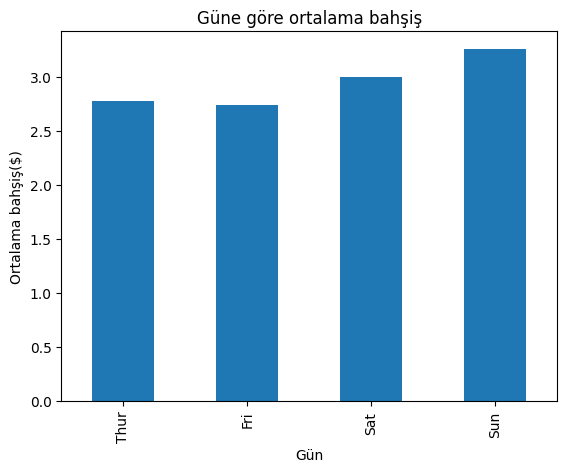

In [ ]:
import matplotlib.pyplot as plt
gune_gore_ortalama.plot(kind="bar")  # çubuk grafiğini çizer
plt.title("Güne göre ortalama bahşiş")
plt.xlabel("Gün")
plt.ylabel("Ortalama bahşiş($)")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

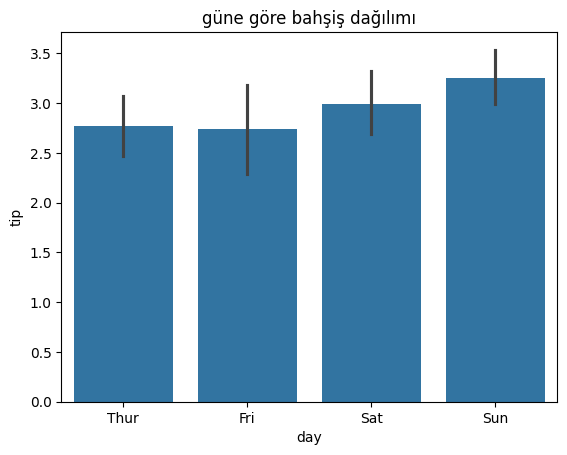

In [ ]:
import seaborn as sns
sns.barplot(data=df , x="day" , y="tip")
plt.title("güne göre bahşiş dağılımı")
plt.show

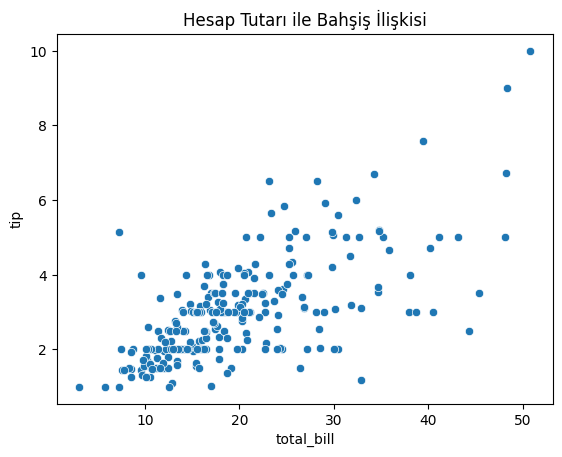

In [ ]:
sns.scatterplot(data=df, x="total_bill", y="tip")
plt.title("Hesap Tutarı ile Bahşiş İlişkisi")
plt.show()

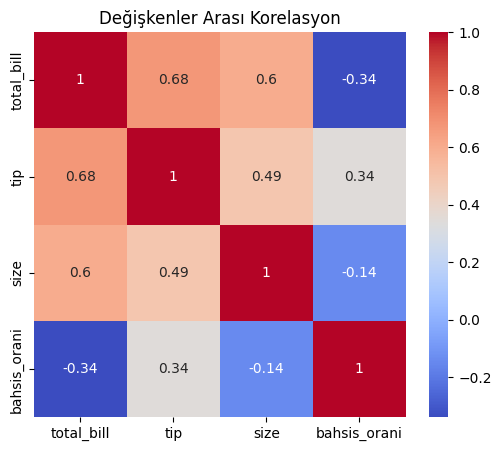

In [ ]:
import seaborn as sns

sayisal_df = df[["total_bill", "tip", "size", "bahsis_orani"]]
plt.figure(figsize=(6, 5))
sns.heatmap(sayisal_df.corr(), annot=True, cmap="coolwarm")
plt.title("Değişkenler Arası Korelasyon")
plt.show()

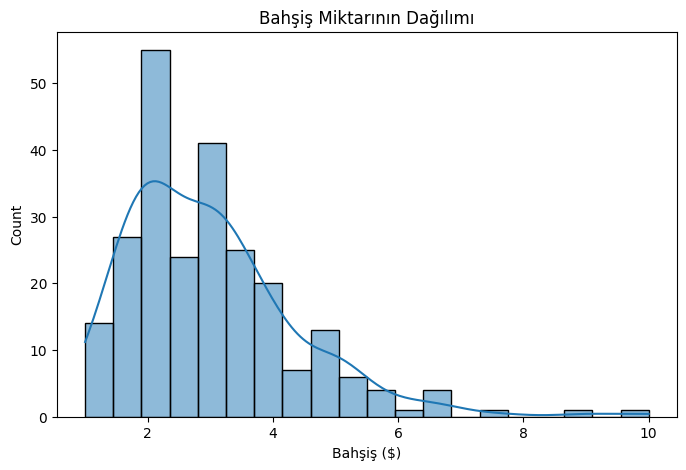

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["tip"], bins=20, kde=True)
plt.title("Bahşiş Miktarının Dağılımı")
plt.xlabel("Bahşiş ($)")
plt.show()

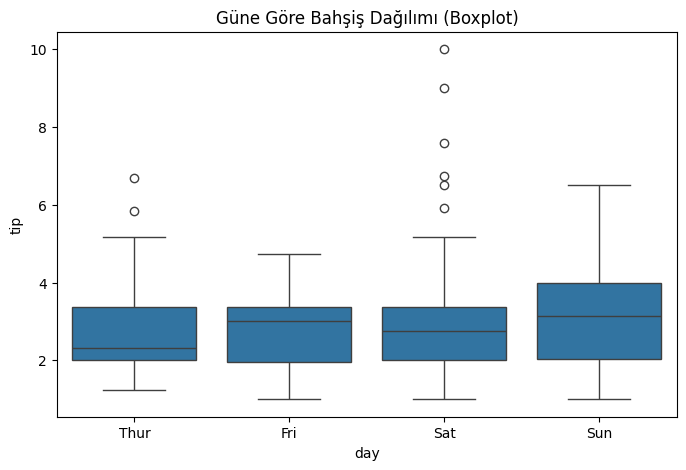

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="day", y="tip")
plt.title("Güne Göre Bahşiş Dağılımı (Boxplot)")
plt.show()

## 6. Özellik Mühendisliği ve Modelleme

Veriden yeni bir öznitelik türetilmiş, ardından bahşiş miktarını tahmin etmek amacıyla farklı makine öğrenmesi modelleri geliştirilmiş ve karşılaştırılmıştır.

In [ ]:
df["bahsis_orani"]=df["tip"]/df["total_bill"]*100
df[["total_bill","tip","bahsis_orani"]].head()

,total_bill,tip,bahsis_orani
0,16.99,1.01,5.944673
1,10.34,1.66,16.054159
2,21.01,3.50,16.658734
3,23.68,3.31,13.978041
4,24.59,3.61,14.680765


In [ ]:
print(df["bahsis_orani"].describe())

count    244.000000
mean      16.080258
std        6.107220
min        3.563814
25%       12.912736
50%       15.476977
75%       19.147549
max       71.034483
Name: bahsis_orani, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
X=df[["total_bill"]]
y=df["tip"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape,X_test.shape)

(195, 1) (49, 1)


In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train, y_train)
print ("katsayı:" , model.coef_)
print ("sabit terim:" ,model.intercept_)

katsayı: [0.10696371]
sabit terim: 0.925235558557056


In [ ]:
tahminler=model.predict(X_test)
print(tahminler[:5])
print (y_test[:5].values)

[3.04525623 1.86330727 3.55119456 3.69452593 2.31576375]
[3.18 2.   2.   5.16 2.  ]


In [ ]:
from sklearn.metrics import mean_absolute_error , r2_score
mae=mean_absolute_error(y_test,tahminler)
r2=r2_score(y_test , tahminler)
print("ortalama mutlak hata:" , mae)
print("R2 skoru:", r2)

ortalama mutlak hata: 0.6208580000398983
R2 skoru: 0.5449381659234664


In [ ]:
X2 = df[["total_bill", "size"]]
y = df["tip"]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)

print("Katsayılar:", model2.coef_)
print("Sabit terim:", model2.intercept_)

Katsayılar: [0.09088117 0.26501754]
Sabit terim: 0.5681370921350064


In [ ]:
tahminler2 = model2.predict(X2_test)

mae2 = mean_absolute_error(y2_test, tahminler2)
r2_2 = r2_score(y2_test, tahminler2)

print("Yeni MAE:", mae2)
print("Yeni R²:", r2_2)

Yeni MAE: 0.6639235737596483
Yeni R²: 0.4811084097989491


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model5 = RandomForestRegressor(random_state=42)
model5.fit(X_train, y_train)
tahmin5 = model5.predict(X_test)

print("Random Forest MAE:", mean_absolute_error(y_test, tahmin5))
print("Random Forest R²:", r2_score(y_test, tahmin5))

Random Forest MAE: 0.8224129251700683
Random Forest R²: 0.19370766751511703


In [ ]:
print("=== Final Model Karşılaştırması ===")
print(f"Linear Regression   -> MAE: {mae:.2f}, R²: {r2:.2f}")
print(f"Random Forest        -> MAE: {mean_absolute_error(y_test, tahmin5):.2f}, R²: {r2_score(y_test, tahmin5):.2f}")
print(f"Aykırı değer sayısı: {len(aykiri)} / {len(df)}")

=== Final Model Karşılaştırması ===
Linear Regression   -> MAE: 0.62, R²: 0.54
Random Forest        -> MAE: 0.82, R²: 0.19
Aykırı değer sayısı: 9 / 244


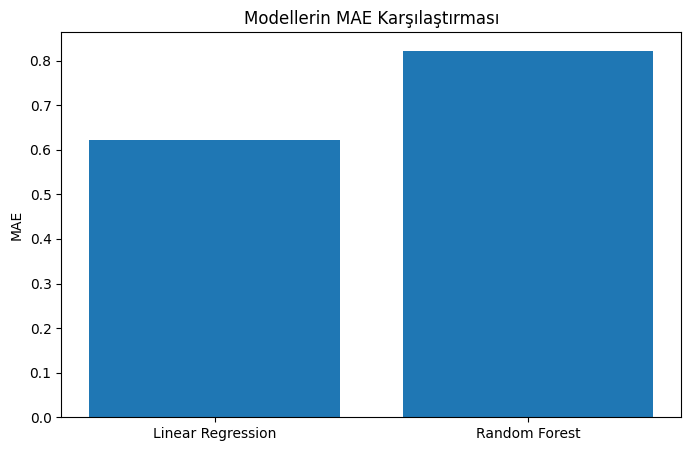

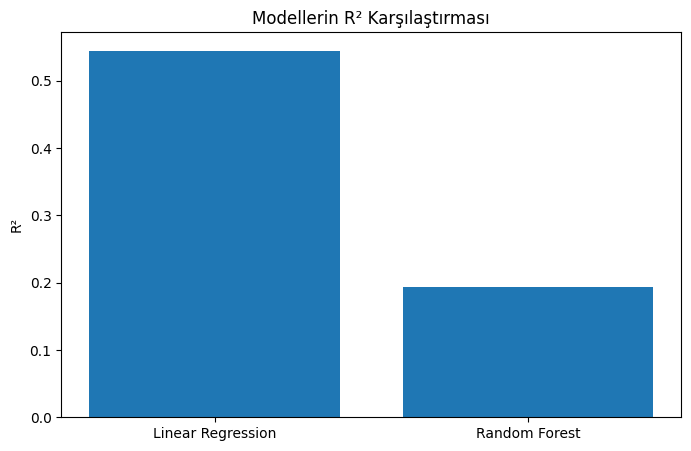

In [ ]:
import matplotlib.pyplot as plt

modeller = ["Linear Regression", "Random Forest"]
mae_degerleri = [mae, mean_absolute_error(y_test, tahmin5)]
r2_degerleri = [r2, r2_score(y_test, tahmin5)]

plt.figure(figsize=(8, 5))
plt.bar(modeller, mae_degerleri)
plt.ylabel("MAE")
plt.title("Modellerin MAE Karşılaştırması")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(modeller, r2_degerleri)
plt.ylabel("R²")
plt.title("Modellerin R² Karşılaştırması")
plt.show()

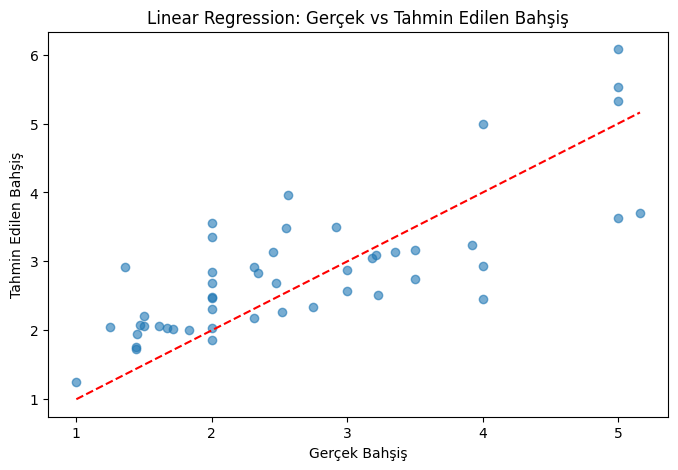

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, tahminler, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Gerçek Bahşiş")
plt.ylabel("Tahmin Edilen Bahşiş")
plt.title("Linear Regression: Gerçek vs Tahmin Edilen Bahşiş")
plt.show()

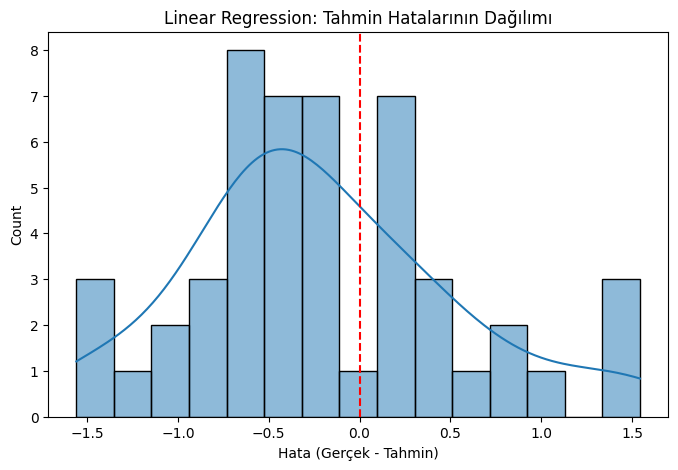

In [ ]:
hatalar = y_test - tahminler
plt.figure(figsize=(8, 5))
sns.histplot(hatalar, bins=15, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Linear Regression: Tahmin Hatalarının Dağılımı")
plt.xlabel("Hata (Gerçek - Tahmin)")
plt.show()

## 7. Sonuç

Bu proje kapsamında, bir restorana ait müşteri verileri üzerinde uçtan uca bir veri analizi ve makine öğrenmesi çalışması gerçekleştirilmiştir. Veri setinin incelenmesi, temizlenmesi, görselleştirilmesi ve yeni bir özniteliğin (bahşiş oranı) türetilmesinin ardından, bahşiş miktarını tahmin etmek amacıyla Linear Regression ve Random Forest Regression modelleri geliştirilmiş ve karşılaştırılmıştır.

Elde edilen sonuçlara göre, bu veri seti ve seçilen öznitelikler kapsamında Linear Regression modeli (MAE: 0.62, R²: 0.54), Random Forest modeline (MAE: 0.82, R²: 0.19) kıyasla daha başarılı bir performans göstermiştir. Bu sonuç, daha karmaşık bir modelin her zaman daha iyi performans göstermeyeceğini; küçük ölçekli ve az sayıda özniteliğe sahip veri setlerinde daha yalın modellerin daha iyi genelleme yapabildiğini ortaya koymuştur.